# Dynex SDK - nBit Adder Native Gate Circuit Example

First we import the required packages:

In [1]:
from pennylane import numpy as np
import pennylane as qml
from dynex import DynexConfig, ComputeBackend, DynexCircuit

config = DynexConfig(compute_backend=ComputeBackend.QPU, qpu_model="apollo_rc1", use_notebook_output=True)

We define our circuit:

In [2]:
params = [25678, 15000]  # two numbers to add


def Nqubits(a, b):
    mxVal = a + b
    return mxVal.bit_length()


wires = Nqubits(*params)


def Kfourier(k, wires):
    for j in range(len(wires)):
        qml.RZ(k * np.pi / (2 ** j), wires=wires[j])


def FullAdder(params, state=True):
    a, b = params
    wires = Nqubits(a, b)
    qml.BasisEmbedding(a, wires=range(wires))
    qml.QFT(wires=range(wires))
    Kfourier(b, range(wires))
    qml.adjoint(qml.QFT)(wires=range(wires))
    if state:
        return qml.state()
    else:
        return qml.sample()

We draw the circuit:

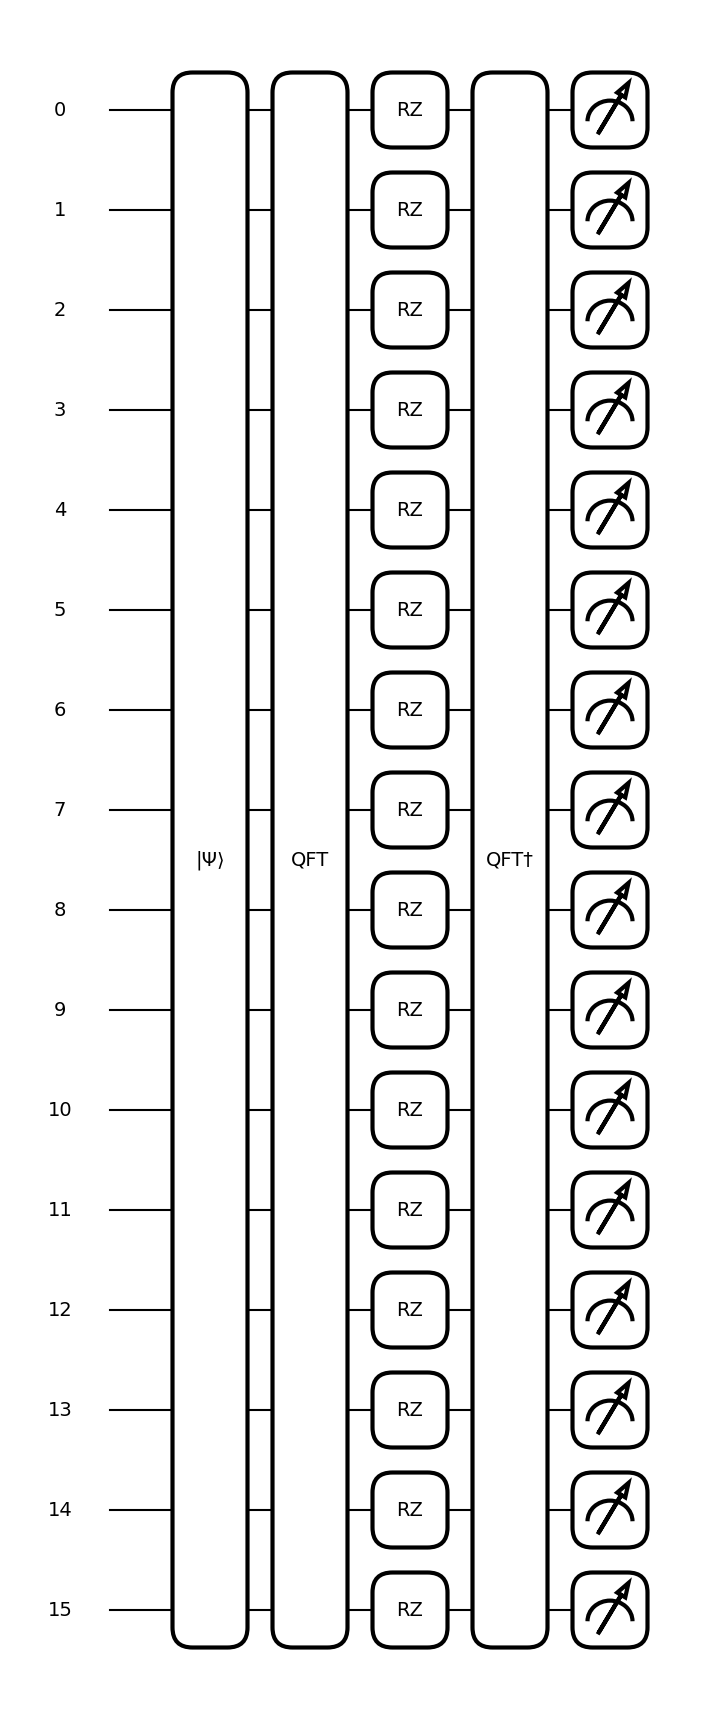

In [3]:
# draw circuit:
_ = qml.draw_mpl(FullAdder, style="black_white")(params)

We execute and measure the circuit on the Dynex platform:

In [4]:
# Execute the circuit on Dynex:
dynex_circuit = DynexCircuit(config=config)
measure = dynex_circuit.execute(FullAdder, params, wires, method="measure",
                                num_reads=1, integration_steps=10, shots=1,
                                qpu_max_coeff=9.0)
print("Mesaure:", measure)

INFO: [DYNEX-APOLLO-RC1] Executing PennyLane quantum circuit
INFO: [DYNEX-APOLLO-RC1] Sampler initialised
INFO: [DYNEX-APOLLO-RC1] Apollo QPU chip: apollo_rc1
INFO: [DYNEX-APOLLO-RC1] Settings: num_reads=1, shots=1, annealing_time=10
INFO: [DYNEX-APOLLO-RC1] Submitting the job to Dynex.
INFO: [DYNEX-APOLLO-RC1] SUCCESS: Job created successfully (job_id=7411)
INFO: [DYNEX-APOLLO-RC1] feed_dict: {'cos_rz_0': 1, 'cos_rz_1': 1, 'cos_rz_10': -0.5245896826784692, 'cos_rz_11': 0.4875501601484358, 'cos_rz_12': 0.8624239561110405, 'cos_rz_13': -0.9649932528549203, 'cos_rz_14': 0.13230031584444468, 'cos_rz_15': 0.7524295036229124, 'cos_rz_2': -1, 'cos_rz_3': -4.553272068345459e-14, 'cos_rz_4': -0.7071067811865315, 'cos_rz_5': 0.3826834323651003, 'cos_rz_6': -0.8314696123025483, 'cos_rz_7': -0.29028467725445967, 'cos_rz_8': -0.5956993044924345, 'cos_rz_9': -0.449611329654606, 'sin_rz_0': -3.6426176546763673e-13, 'sin_rz_1': -1.8213088273381836e-13, 'sin_rz_10': -0.851355193105265, 'sin_rz_11': -0

Mesaure: [1 0 0 1 1 1 1 0 1 1 1 0 0 1 1 0]


In [5]:
bitStr = "".join(map(str, measure.astype(int)))
dynexResult = int(bitStr, 2)
print("Dynex Result:", dynexResult)
print("Expected Result:", sum(params))
isValidDynex = dynexResult == sum(params)
print("Is Dynex Result Valid?", isValidDynex)

Dynex Result: 40678
Expected Result: 40678
Is Dynex Result Valid? True
